dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
---- Internal Validation Metrics ----
K=10:
  MSE: 0.0009
  MAE: 0.0227
  RMSE: 0.0294
  R2: 0.6663
K=15:
  MSE: 0.0009
  MAE: 0.0224
  RMSE: 0.0292
  R2: 0.6661
K=20:
  MSE: 0.0009
  MAE: 0.0227
  RMSE: 0.0294
  R2: 0.6558
---- External Validation Metrics ----
K=10:
  MSE: 0.0009
  MAE: 0.0227
  RMSE: 0.0294
  R2: 0.6663
K=15:
  MSE: 0.0009
  MAE: 0.0224
  RMSE: 0.0292
  R2: 0.6661
K=20:
  MSE: 0.0009
  MAE: 0.0227
  RMSE: 0.0294
  R2: 0.6558


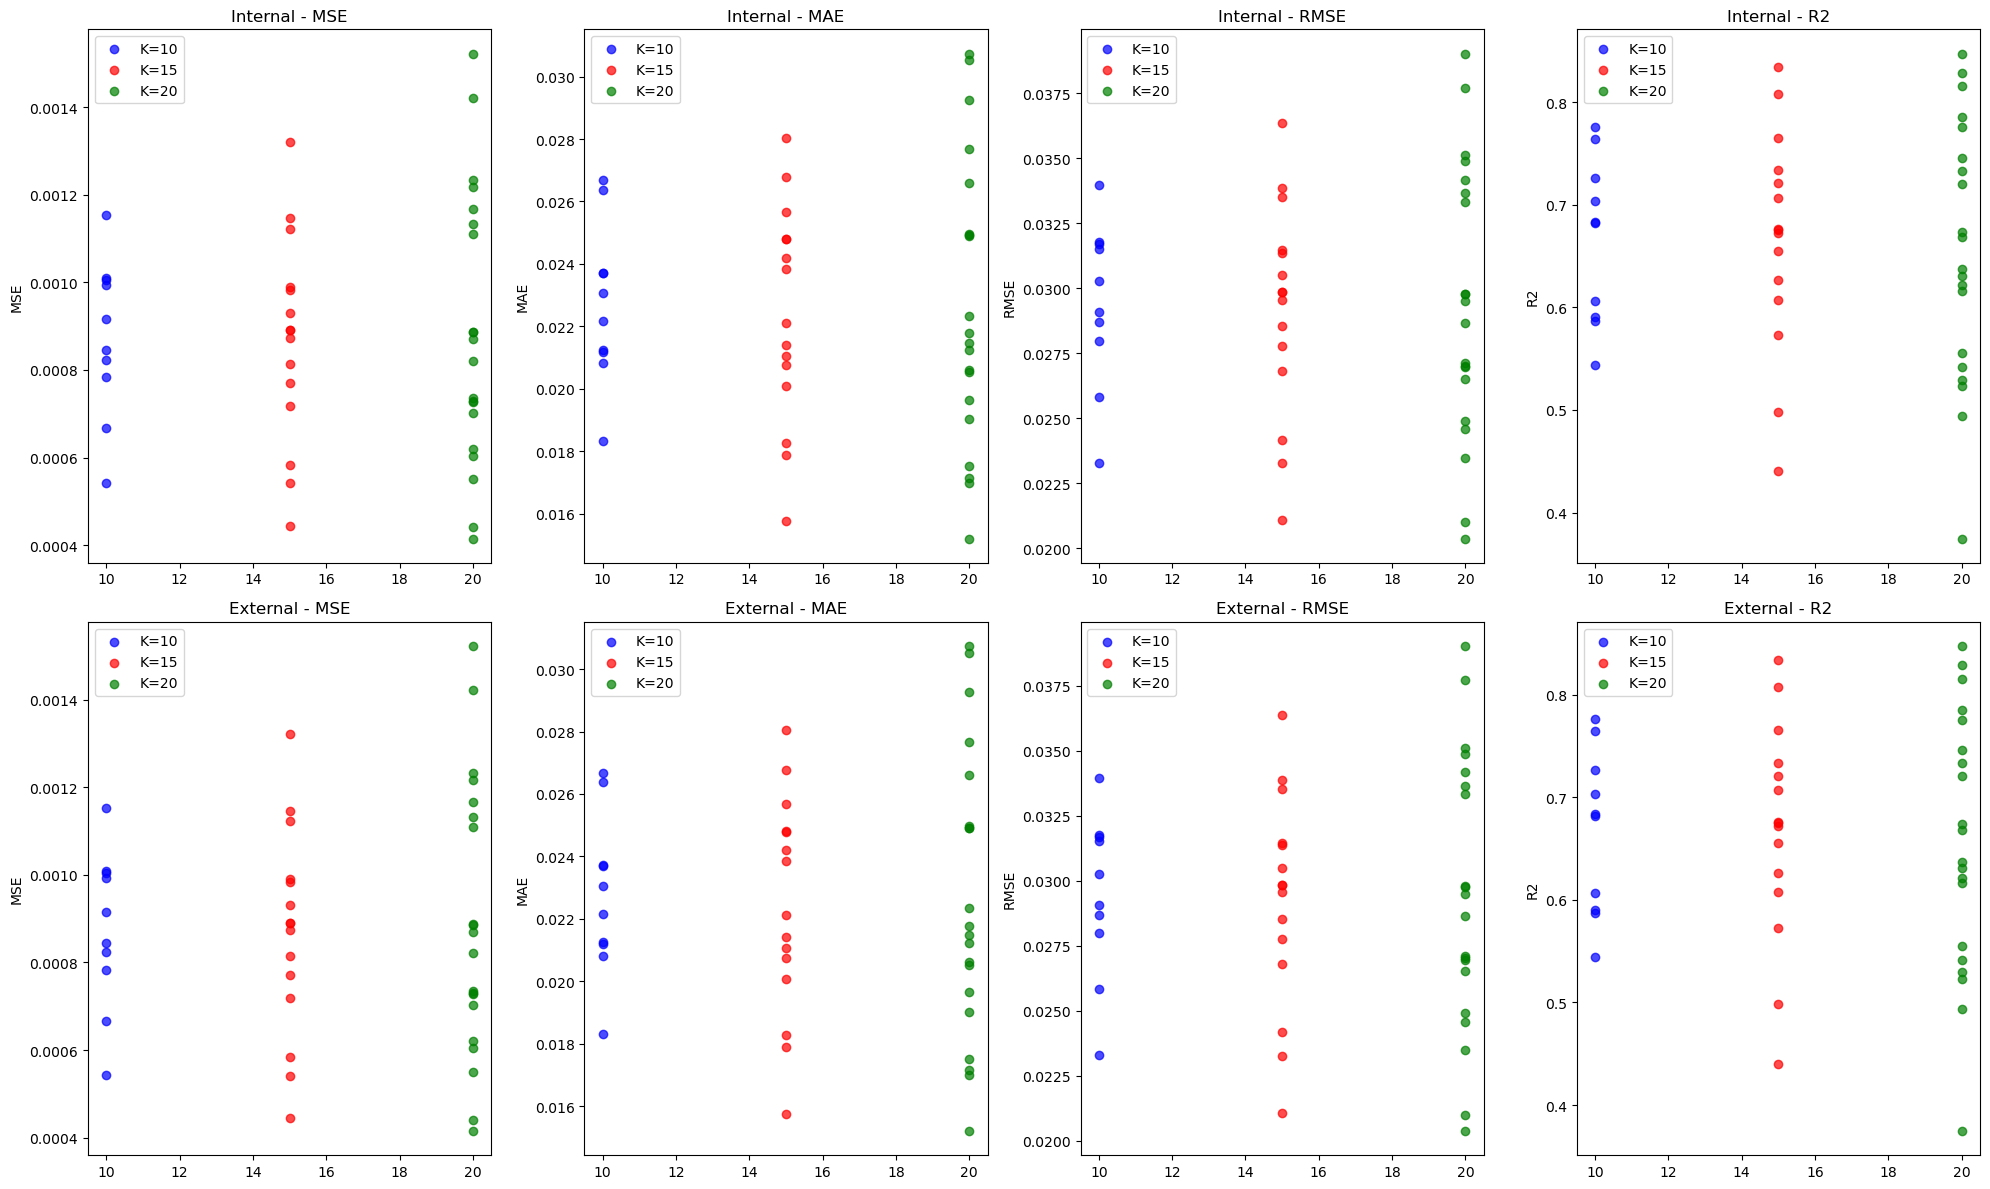

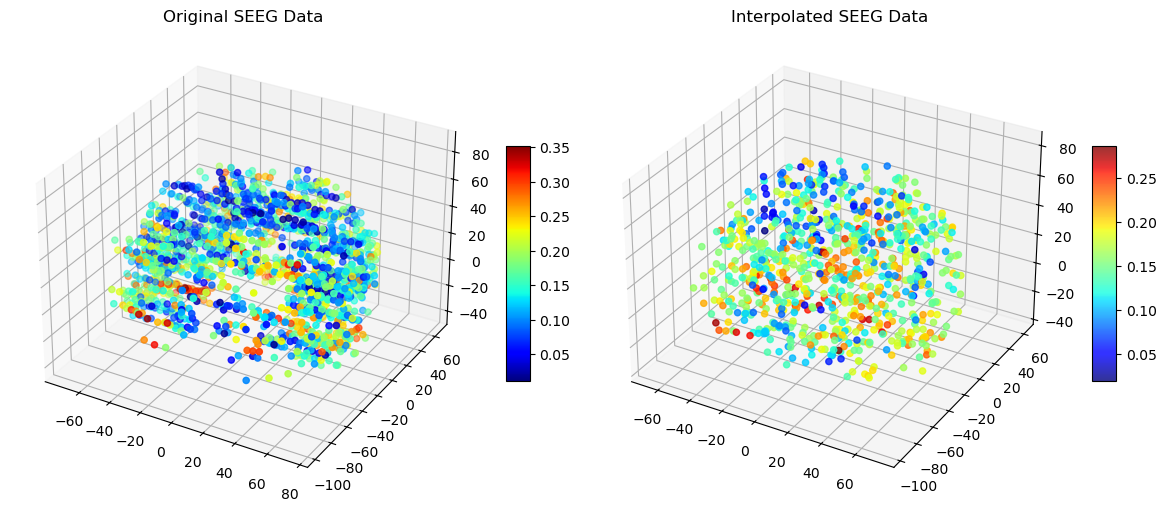

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

def load_data():
    coords = np.load('coords.npy')
    band_powers = np.load('band_powers.npy', allow_pickle=True).item()
    print(band_powers.keys())
    return coords, band_powers

def interpolate_smooth(coords, values, method='linear'):
    grid_x = np.linspace(coords[:, 0].min(), coords[:, 0].max(), len(coords))
    grid_y = np.linspace(coords[:, 1].min(), coords[:, 1].max(), len(coords))
    grid_z = np.linspace(coords[:, 2].min(), coords[:, 2].max(), len(coords))
    
    grid_coords = np.column_stack([
        np.random.choice(grid_x, size=len(coords)),  
        np.random.choice(grid_y, size=len(coords)),  
        np.random.choice(grid_z, size=len(coords))
    ])
    
    interp_values = griddata(coords, values, grid_coords, method='linear')
    return grid_coords, interp_values

def calculate_metrics(true_values, pred_values):
    mask = ~np.isnan(pred_values) 
    mse = mean_squared_error(true_values[mask], pred_values[mask])
    mae = mean_absolute_error(true_values[mask], pred_values[mask])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values[mask], pred_values[mask])
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

def cross_validate(coords, values, k_values, validation_type="Internal", band="Unknown"):
    results = {k: {"MSE": [], "MAE": [], "RMSE": [], "R2": []} for k in k_values}
    scaler = StandardScaler()
    coords = scaler.fit_transform(coords)
    
    for k in k_values:
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        for train_idx, test_idx in kf.split(coords):
            train_coords, test_coords = coords[train_idx], coords[test_idx]
            train_values, test_values = values[train_idx], values[test_idx]
            pred_values = griddata(train_coords, train_values, test_coords, method='linear')
            metrics = calculate_metrics(test_values, pred_values)
            for metric in results[k]:
                results[k][metric].append(metrics[metric])
    return results

def plot_all_metrics(internal_metrics, external_metrics, band, k_values):
    colors = {10: 'blue', 15: 'red', 20: 'green'}
    metrics = ["MSE", "MAE", "RMSE", "R2"]
    fig, axes = plt.subplots(2, len(metrics), figsize=(20, 12))  
    
    for i, metric in enumerate(metrics):
        for k in k_values:
            axes[0, i].scatter([k] * len(internal_metrics[k][metric]), internal_metrics[k][metric], color=colors[k], label=f'K={k}', alpha=0.7)
            axes[1, i].scatter([k] * len(external_metrics[k][metric]), external_metrics[k][metric], color=colors[k], label=f'K={k}', alpha=0.7)
        
        axes[0, i].set_title(f"Internal - {metric}")
        axes[1, i].set_title(f"External - {metric}")
        axes[0, i].set_ylabel(metric)
        axes[1, i].set_ylabel(metric)
        axes[0, i].legend()
        axes[1, i].legend()
    
    plt.tight_layout()
    plt.show()

def print_metrics(metrics_results, evaluation_type):
    print(f"---- {evaluation_type} Validation Metrics ----")
    for k, metrics in metrics_results.items():
        print(f"K={k}:")
        for metric_name, values in metrics.items():
            avg_value = np.mean(values)
            print(f"  {metric_name}: {avg_value:.4f}")

def main():
    coords, band_powers = load_data()
    band = 'Delta' 
    if band not in band_powers:
        print(f"Band {band} not found in data.")
        return
    
    band_values = np.array(band_powers[band])
    interp_coords, interp_values = interpolate_smooth(coords, band_values, method='linear')
    
    k_values = [10, 15, 20]
    internal_metrics = cross_validate(interp_coords, interp_values, k_values, validation_type="Internal", band=band)
    external_metrics = cross_validate(interp_coords, interp_values, k_values, validation_type="External", band=band)
    
    print_metrics(internal_metrics, "Internal")
    print_metrics(external_metrics, "External")
    plot_all_metrics(internal_metrics, external_metrics, band, k_values)
    
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=band_values, cmap='jet', marker='o')
    ax1.set_title("Original SEEG Data")
    fig.colorbar(scatter1, ax=ax1, shrink=0.5, aspect=10)
    
    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(interp_coords[:, 0], interp_coords[:, 1], interp_coords[:, 2], c=interp_values, cmap='jet', marker='o', alpha=0.8)
    ax2.set_title("Interpolated SEEG Data")
    fig.colorbar(scatter2, ax=ax2, shrink=0.5, aspect=10)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()